# Practica M26

En este ejercicio usaremos Clustering jerárquico para hacer recomendaciones de compras a los clientes. La idea consiste en recomendar a un cliente los productos que ha comprado otra persona que pertenece al mismo clúster o segmento.

El objetivo de esta actividad es que realices un análisis de agrupación por “Clustering Jerárquico” a una base de datos de manera que  puedas generar conclusiones de acuerdo a diversas categorías.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('amazon.xlsx')
df

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43
...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1
96,Teofil,305,25,46,24,33,28,355,26,45
97,Teofila,1,14,26,25,24,27,42,185,23
98,Teon,155,11,335,34,26,29,42,215,27


In [3]:
#Guardar nombres para despues
df_names = df['Unnamed: 0']
df_names

0        Adam
1        Anna
2     Bernard
3      Edward
4      Emilia
       ...   
95     Teofan
96     Teofil
97    Teofila
98       Teon
99     Teresa
Name: Unnamed: 0, Length: 100, dtype: object

In [4]:
#Quitar nombres  para quedarme solo con numeros en el df
df.drop(columns=['Unnamed: 0'], axis=1, inplace=True)
df

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,205,3,345,235,24,23,26,21,17
1,9,15,315,33,25,4,42,215,28
2,17,26,285,3,43,27,41,26,33
3,135,5,355,295,18,23,39,195,17
4,3,45,48,39,34,46,225,34,43
...,...,...,...,...,...,...,...,...,...
95,3,8,32,25,7,21,42,17,1
96,305,25,46,24,33,28,355,26,45
97,1,14,26,25,24,27,42,185,23
98,155,11,335,34,26,29,42,215,27


* ### Con base en los resultados de su análisis, ¿qué productos recomendaría a Salomé? ¿Qué productos recomendaría a Stephanía? ¿Qué productos recomendaría a Lydia? La respuesta debe estar reflejada en función de otros clientes. Por ejemplo, “Recomendaría a Salomé los mismos productos que compró XXXXX”. Dé nombres de clientes en cada caso. Expliqué claramente sus conclusiones.

In [5]:
# Normalizado de datos
from sklearn.preprocessing import normalize
data_scaled = normalize(df)
data_scaled
data_scaled = pd.DataFrame(data_scaled, columns = df.columns) 
data_scaled

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
1,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
2,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
3,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
4,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642
...,...,...,...,...,...,...,...,...,...
95,0.045932,0.122484,0.489936,0.382763,0.107174,0.321521,0.643041,0.260279,0.015311
96,0.640241,0.052479,0.096561,0.050380,0.069272,0.058776,0.745198,0.054578,0.094462
97,0.005043,0.070602,0.131118,0.126075,0.121032,0.136161,0.211805,0.932952,0.115989
98,0.357707,0.025386,0.773109,0.078465,0.060003,0.066926,0.096927,0.496175,0.062310


<function matplotlib.pyplot.show(close=None, block=None)>

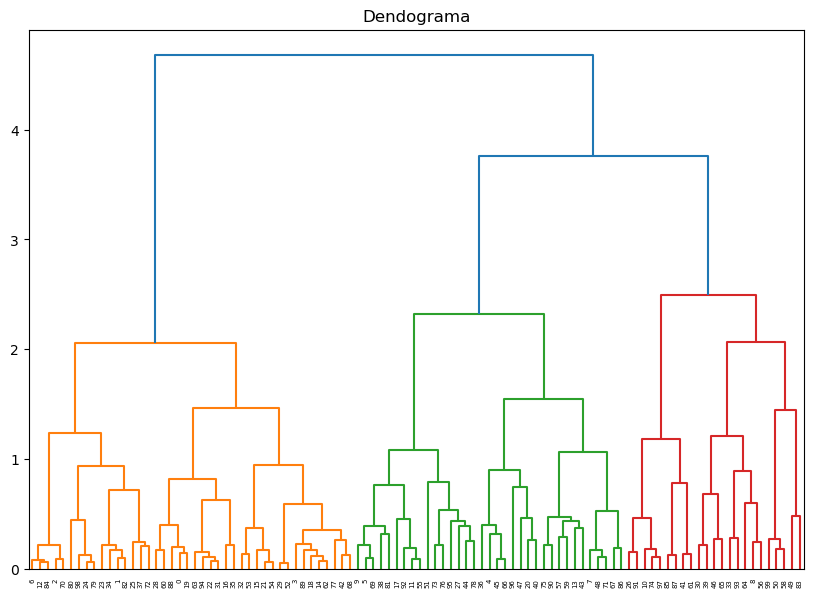

In [6]:
# Visualizacion y analisis de Dendograma
import scipy.cluster.hierarchy as shc
plt.figure(figsize = (10,7))
plt.title('Dendograma')
dend = shc.dendrogram(shc.linkage(data_scaled,method='ward'))
plt.show

In [7]:
print(dend['color_list'])

['C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C0', 'C0']


In [8]:
colores_unicos = set(dend['color_list'])
colores_unicos

{'C0', 'C1', 'C2', 'C3'}

In [9]:
num_clusters_optimo = len(colores_unicos) - 1
num_clusters_optimo

3

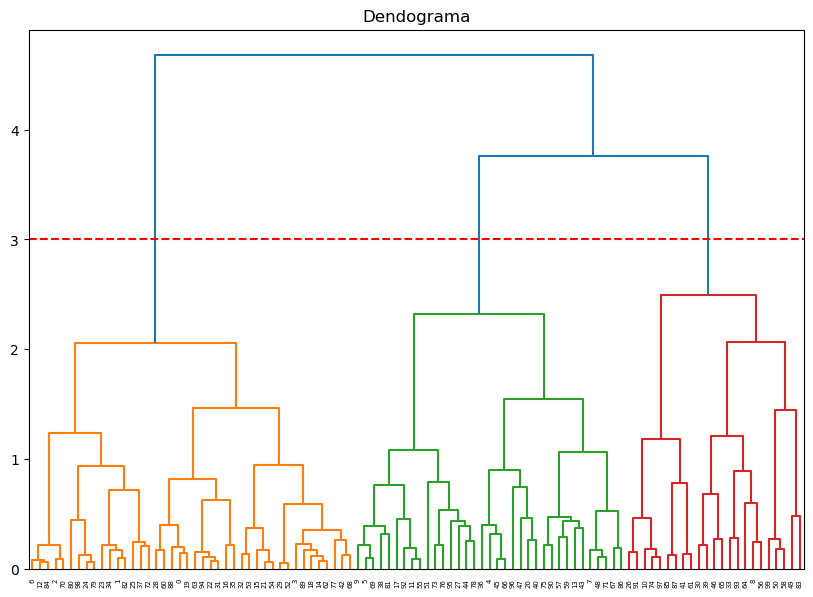

In [10]:
plt.figure(figsize=(10,7))
plt.title('Dendograma')
dend = shc.dendrogram(shc.linkage(data_scaled, method = 'ward'))
plt.axhline(y=3, color= 'r', linestyle = '--')

In [12]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters = 3, metric= 'euclidean', linkage = 'ward')
grupos = cluster.fit_predict(data_scaled)
grupos

array([1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0])

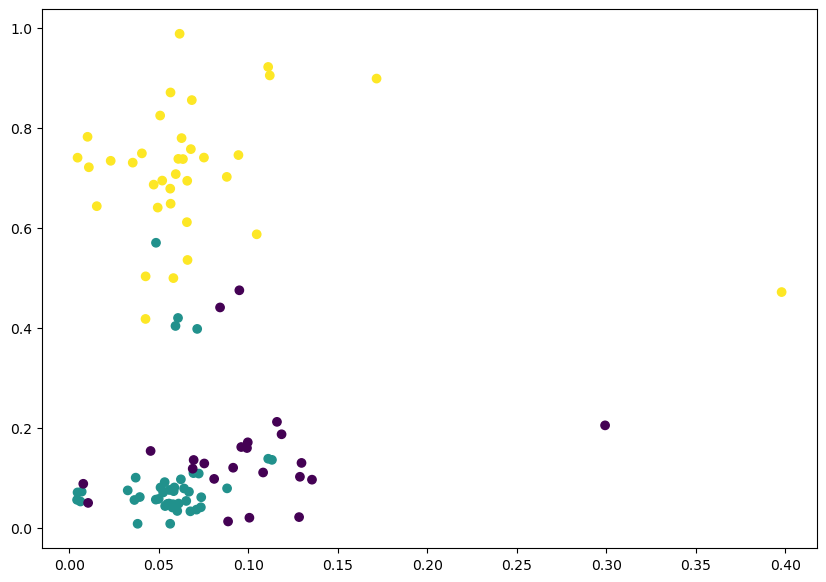

In [17]:
plt.figure(figsize= (10,7))
plt.scatter(data_scaled['Numero Estrellas'],data_scaled['Tamano Paquete'], c = cluster.labels_)
# usando los datos sin PCA se ven muy revueltos 

In [18]:

campos = data_scaled.values
print(campos)

[[0.43826336 0.00641361 0.73756517 0.50239946 0.05130888 0.04917101
  0.05558462 0.04489527 0.03634379]
 [0.02323527 0.03872544 0.81323434 0.08519598 0.06454241 0.01032679
  0.10843125 0.55506471 0.0722875 ]
 [0.05723452 0.08753514 0.95951982 0.01010021 0.14476966 0.09090188
  0.13803618 0.08753514 0.11110229]
 [0.25885639 0.00958727 0.68069644 0.56564916 0.03451419 0.04410146
  0.07478074 0.37390368 0.03259673]
 [0.01197502 0.17962533 0.19160036 0.15567529 0.13571692 0.18361701
  0.89812667 0.13571692 0.17164198]
 [0.14494006 0.251738   0.60264551 0.03661644 0.03966781 0.02898801
  0.73995715 0.03356507 0.00457705]
 [0.04755854 0.02481315 0.98218723 0.06823617 0.07237169 0.09304932
  0.07857498 0.05996511 0.06410064]
 [0.13323393 0.04304481 0.06354234 0.52268696 0.05739308 0.04509456
  0.70716471 0.44069685 0.05944283]
 [0.73804829 0.0214705  0.12613916 0.63069581 0.09393342 0.00805144
  0.10198485 0.07246292 0.12882297]
 [0.00348086 0.30457545 0.56564012 0.00522129 0.06439595 0.05569

In [21]:
# Separacion de grupos mediante PCA
from sklearn import decomposition
pca = decomposition.PCA(n_components = 2 )
pca.fit(campos)
campos = pca.transform(campos)
campos

array([[ 0.39993219, -0.06035374],
       [ 0.40829583,  0.06402268],
       [ 0.49703182,  0.35955286],
       [ 0.33996675, -0.18434501],
       [-0.58207751,  0.38797653],
       [-0.1723403 ,  0.52962573],
       [ 0.56528441,  0.33770585],
       [-0.5335887 , -0.06994712],
       [-0.09981604, -0.47165743],
       [-0.22195207,  0.56503313],
       [-0.08274005, -0.39712712],
       [ 0.00143465,  0.48936583],
       [ 0.57292039,  0.35927774],
       [-0.51350639, -0.01301312],
       [ 0.35272162, -0.20639728],
       [ 0.4688626 , -0.0168001 ],
       [ 0.25142488, -0.04599019],
       [ 0.05456876,  0.22302796],
       [ 0.36123131, -0.20553368],
       [ 0.41087067, -0.02173183],
       [-0.54207892,  0.03308916],
       [ 0.5138909 ,  0.0900875 ],
       [ 0.4284552 ,  0.0601418 ],
       [ 0.42320562,  0.09945498],
       [ 0.42610215, -0.06318626],
       [ 0.10615885,  0.20376697],
       [-0.19058214, -0.3966612 ],
       [ 0.096838  ,  0.33104612],
       [ 0.51505714,

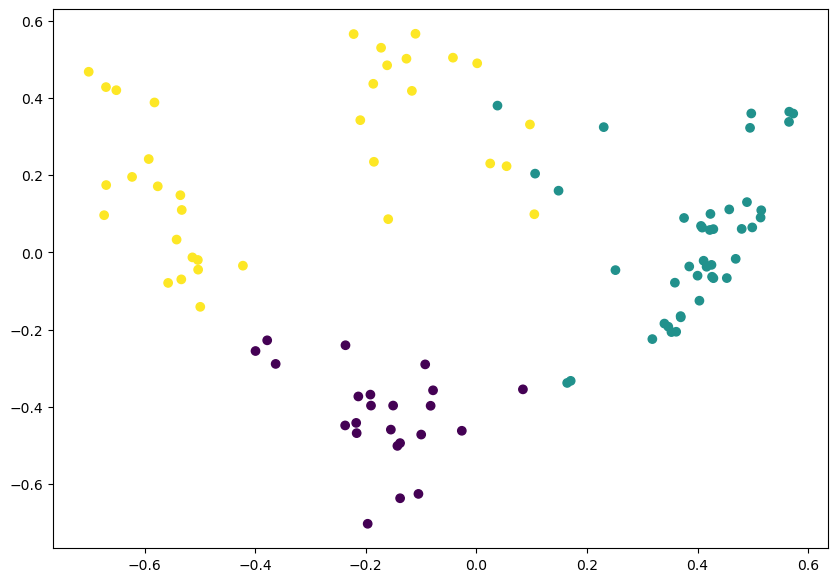

In [28]:
plt.figure(figsize=(10,7))
plt.scatter(campos[:,0],campos[:,1], c= cluster.labels_)
# Los grupos ya se ven mejor definidos

In [23]:
dataframe = pd.DataFrame(grupos, columns = ['grupo'])
dataframe

,grupo
0,1
1,1
2,1
3,1
4,2
...,...
95,2
96,2
97,0
98,1


In [29]:
df_final = pd.concat([df, dataframe], axis = 1, join = 'inner')
df_final.index = df_names
df_final

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
Unnamed: 0,,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17,1
Anna,9,15,315,33,25,4,42,215,28,1
Bernard,17,26,285,3,43,27,41,26,33,1
Edward,135,5,355,295,18,23,39,195,17,1
Emilia,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...
Teofan,3,8,32,25,7,21,42,17,1,2
Teofil,305,25,46,24,33,28,355,26,45,2
Teofila,1,14,26,25,24,27,42,185,23,0


In [61]:
#Salomé, Stephanía, ,Lydia
print(df_final.loc['Lydia'], '\n')
print(df_final.loc['Stephania'], '\n')
print(df_final.loc['Salome'])

Velocidad Entrega     19
Precio                 4
Durabilidad          435
Imagen Producto      145
Valor Educativo       16
Servicio Retorno      21
Tamano Paquete        28
Calidad Producto     185
Numero Estrellas      24
grupo                  1
Name: Lydia, dtype: int64 

Velocidad Entrega    215
Precio               125
Durabilidad          465
Imagen Producto      315
Valor Educativo       34
Servicio Retorno       4
Tamano Paquete        37
Calidad Producto     305
Numero Estrellas      45
grupo                  1
Name: Stephania, dtype: int64 

Velocidad Entrega     17
Precio                23
Durabilidad          275
Imagen Producto       41
Valor Educativo        4
Servicio Retorno      44
Tamano Paquete       315
Calidad Producto      28
Numero Estrellas      32
grupo                  2
Name: Salome, dtype: int64


## Lydia
Lydia parece tener una fuerte preferencia por productos con alta durabilidad, calidad y buena imagen, asi como poca prioridad en el numero de estrellas, precio o logistica de envio o retorno en general, por lo que buscare una persona en el grupo 1 que tenga esa misma preferencia

In [69]:
columnas = ['Durabilidad', 'Calidad Producto', 'Imagen Producto', 'Numero Estrellas', 'Precio']

# Filtrar solo el grupo de Lydia
grupo_lydia = df_final[df_final['grupo'] == df_final.loc['Lydia', 'grupo']]
diferencias = grupo_lydia[columnas].sub(df_final.loc['Lydia', columnas]).abs().sum(axis=1)
diferencias = diferencias.drop('Lydia').sort_values()
print(diferencias)

Unnamed: 0
Fedir           84
Mykyta         157
Maura          180
Myroslava      191
Flavia         194
Joseph         203
Myroslav       213
Lubomyr        215
Ivan           221
Edward         248
Teon           251
Jervis         256
Methodius      260
Hannah         268
Samuel         275
Anna           277
Fialka         295
Markian        299
Irene          322
Philip         323
Lourdes        324
Sarah          334
Eunice         338
Judith         345
Adam           352
Flora          377
Theodore       392
Hilary         399
Marian         407
Felix          411
Stephan        420
Isidore        436
Marko          442
Maximillian    446
Stephania      462
Jacob          468
Bernard        482
Eva            513
Helen          528
Louise         572
Eugene         625
dtype: int64


Para el caso de Lydia yo le recomendaria productos que tambien le interesen a Fedir ya que tienen los gustos mas similares al tener un valor absoluto menor. como referencia el valor perfecto seria 0, pero unicamente con la muestra proporcionada solo comparando a Lydia con ella misma daria este resultado. 

***
## Stephania

Stephania es similar a Lydia, pero prioriza mas el precio, la velocidad de entrega y la calidad y no le interesa tanto el servicio de retorno. 

In [71]:
columnas = ['Durabilidad', 'Calidad Producto', 'Imagen Producto', 'Velocidad Entrega', 'Precio']

# Filtrar solo el grupo de Stephania
grupo_lydia = df_final[df_final['grupo'] == df_final.loc['Stephania', 'grupo']]
diferencias = grupo_lydia[columnas].sub(df_final.loc['Stephania', columnas]).abs().sum(axis=1)
diferencias = diferencias.drop('Stephania').sort_values()
print(diferencias)

Unnamed: 0
Judith          140
Isidore         140
Markian         160
Eunice          208
Louise          290
Helen           330
Lourdes         333
Maura           350
Mykyta          382
Eva             432
Edward          440
Marian          491
Joseph          492
Myroslav        499
Flavia          539
Flora           578
Myroslava       582
Hannah          599
Stephan         602
Adam            616
Lubomyr         634
Lydia           637
Hilary          637
Jervis          641
Felix           652
Teon            675
Methodius       692
Fedir           701
Jacob           713
Fialka          794
Ivan            801
Eugene          802
Theodore        836
Anna            838
Marko           850
Samuel          861
Philip          873
Sarah           941
Irene           958
Maximillian    1027
Bernard        1068
dtype: int64


Para el caso de Stephania le recomendaria mas productos de Judith o Isidore ya que tomando encuenta sus prioridades, parecen tener datos muy similares

***
## Salome

Salome pertenece a un grupo donde se prioriza mas el tamaño del paquete y la durabilidad, mas que la imagen del producto o el precio

In [73]:
columnas = ['Durabilidad', 'Precio', 'Imagen Producto', 'Valor Educativo', 'Tamano Paquete']

# Filtrar solo el grupo de Salome
grupo_lydia = df_final[df_final['grupo'] == df_final.loc['Salome', 'grupo']]
diferencias = grupo_lydia[columnas].sub(df_final.loc['Salome', columnas]).abs().sum(axis=1)
diferencias = diferencias.drop('Salome').sort_values()
print(diferencias)

Unnamed: 0
Sylvester     76
Magdalyna    220
Joachim      303
Evdokia      310
Henry        311
Teofil       317
Kalyna       334
Eugenia      348
Santiago     353
Emilia       371
Larissa      381
Gabriel      393
Melania      410
Maryna       420
Maya         458
Leonard      458
Jeremiah     462
Fabian       471
Michael      485
Monica       491
Frank        514
Myron        527
Teofan       550
Leo          553
Florence     564
Isabelle     571
Mina         581
Leon         604
Justin       625
Marcel       633
Susanna      640
Sebastian    652
Matthew      710
Maria        816
dtype: int64


A Salome le recomendaria productos que tambien le gustan a Sylvester ya que tienen buena similitud con las variables que mas/menos prioriza salome.  